# Week 18 — Tuesday (Jul 21): Pruning & Quantization

## Learning Objectives
- Understand unstructured vs structured weight pruning, and why zeroing weights alone doesn't shrink a dense model on a commodity CPU
- Apply L1 magnitude pruning to a trained CNN and measure the real accuracy / sparsity trade-off
- Build a genuinely smaller model via structured (channel) pruning and measure real size + latency wins
- Apply INT8 post-training quantization — both dynamic and static (FX graph mode) — and measure real size + latency wins
- Understand knowledge distillation and train a small "student" model with a distillation loss vs. plain supervised training
- Produce one honest CPU benchmark table comparing baseline vs pruned vs quantized vs distilled variants

## Key Concepts
1. **Unstructured pruning** — zero out individual low-magnitude weights; sparsity pattern is irregular
2. **Structured pruning** — remove entire channels/filters; produces a smaller *dense* tensor that is actually faster to run
3. **The pruning trap** — `torch.nn.utils.prune` masks weights to zero but keeps the tensor shape unchanged, so file size and FLOPs are usually **unaffected** unless you physically slice out the zeroed structure or use a sparse-aware runtime
4. **Quantization** — represent weights/activations with INT8 instead of FP32 → ~4x smaller, and faster on CPU via vectorised INT8 kernels
5. **Dynamic quantization** — weights are quantized ahead of time; activations are quantized on-the-fly per batch (best fit for `nn.Linear` / RNNs)
6. **Static quantization** — weights *and* activations are quantized using a short calibration pass; needs Conv+BN+ReLU fusion and observers, but covers Conv layers too
7. **Knowledge distillation** — a small "student" network learns from a larger "teacher"'s softened output distribution (KL loss) in addition to the ground-truth labels

In [1]:
import io
import os
import copy
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.prune as prune
import torch.ao.quantization as tq
import torch.ao.quantization.quantize_fx as quantize_fx
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Week 18 — Pruning & Quantization (this whole notebook runs on CPU by design — the deployment target)')

PyTorch 2.12.0+cpu | Device: cpu
Week 18 — Pruning & Quantization (this whole notebook runs on CPU by design — the deployment target)


## Section 1: Baseline Model — Train a Small CNN Classifier

Everything in this notebook prunes/quantizes/distils the **same baseline model**, so every
comparison is apples-to-apples. We train a small CNN on a subset of MNIST — small enough
to train in seconds on CPU, but with enough real structure (Conv + BatchNorm + Linear) that
pruning and quantization behave the way they would on a real deployment target.

In [2]:
class TinyCNN(nn.Module):
    '''Small conv classifier: 2x (Conv-BN-ReLU-Pool) + 2x Linear. Input: (B,1,28,28).'''
    def __init__(self, num_classes=10, c1=8, c2=16, fc_hidden=64):
        super().__init__()
        self.conv1 = nn.Conv2d(1, c1, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(c1)
        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(c2)
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(c2 * 7 * 7, fc_hidden)
        self.fc2   = nn.Linear(fc_hidden, num_classes)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = x.flatten(1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)


# ── MNIST subset (reuse the copy already downloaded for Week 15) ─────────────
MNIST_ROOT = '../Week_01/data'
tf = transforms.Compose([transforms.ToTensor()])
train_full = torchvision.datasets.MNIST(root=MNIST_ROOT, train=True,  download=True, transform=tf)
test_full  = torchvision.datasets.MNIST(root=MNIST_ROOT, train=False, download=True, transform=tf)

N_TRAIN, N_TEST = 4000, 1500
train_ds = Subset(train_full, list(range(N_TRAIN)))
test_ds  = Subset(test_full,  list(range(N_TEST)))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=256, shuffle=False)
print(f'Train: {N_TRAIN} samples | Test: {N_TEST} samples')

@torch.no_grad()
def evaluate(model, loader=test_dl):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        out = model(x)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total

def train_model(model, loader=train_dl, epochs=5, lr=1e-3, teacher=None, alpha=0.5, T=4.0):
    '''Standard supervised training; if `teacher` is given, adds a KD loss term.'''
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    if teacher is not None:
        teacher.eval()
    for ep in range(epochs):
        for x, y in loader:
            opt.zero_grad()
            out = model(x)
            loss = F.cross_entropy(out, y)
            if teacher is not None:
                with torch.no_grad():
                    t_out = teacher(x)
                kd = F.kl_div(F.log_softmax(out / T, dim=1),
                               F.softmax(t_out / T, dim=1),
                               reduction='batchmean') * (T * T)
                loss = alpha * loss + (1 - alpha) * kd
            loss.backward()
            opt.step()
        model.eval()
    return model

def model_size_kb(model):
    '''Serialized state_dict size — the honest proxy for 'file size on disk'.'''
    buf = io.BytesIO()
    torch.save(model.state_dict(), buf)
    return len(buf.getvalue()) / 1024

def bench_latency_ms(model, x=None, n_warmup=10, n_runs=100):
    model.eval()
    if x is None:
        x = torch.randn(1, 1, 28, 28)
    with torch.no_grad():
        for _ in range(n_warmup):
            model(x)
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            model(x)
            times.append(time.perf_counter() - t0)
    return np.mean(times) * 1000

torch.manual_seed(42)
baseline = TinyCNN().to(DEVICE)
t0 = time.perf_counter()
train_model(baseline, epochs=5)
train_time = time.perf_counter() - t0

baseline_acc  = evaluate(baseline)
baseline_size = model_size_kb(baseline)
baseline_lat  = bench_latency_ms(baseline)
baseline_params = sum(p.numel() for p in baseline.parameters())

print(f'Baseline trained in {train_time:.1f}s')
print(f'  Params  : {baseline_params:,}')
print(f'  Accuracy: {baseline_acc*100:.2f}%')
print(f'  Size    : {baseline_size:.1f} KB')
print(f'  Latency : {baseline_lat:.3f} ms/image (CPU, batch=1)')

Train: 4000 samples | Test: 1500 samples


Baseline trained in 3.8s
  Params  : 52,186
  Accuracy: 95.93%
  Size    : 209.8 KB
  Latency : 0.243 ms/image (CPU, batch=1)


## Section 2: Unstructured Pruning — L1 Magnitude

`torch.nn.utils.prune.l1_unstructured` masks the smallest-magnitude weights to zero. It's
the textbook introduction to pruning, but it has a catch that's easy to miss: the pruned
tensor is still stored **dense** — the zeros are real floats sitting in memory — so
serialized size and FLOPs are unaffected unless something downstream (a sparse kernel, a
sparse tensor format) actually exploits the zero pattern. We measure this honestly below
instead of asserting savings that a CPU deployment wouldn't actually see.

target=0.00  actual_sparsity=  0.0%  acc=95.93%  size= 209.8 KB  latency=0.234 ms


target=0.30  actual_sparsity= 30.0%  acc=93.13%  size= 209.8 KB  latency=0.280 ms


target=0.50  actual_sparsity= 50.0%  acc=74.87%  size= 209.8 KB  latency=0.232 ms


target=0.70  actual_sparsity= 70.0%  acc=19.13%  size= 209.8 KB  latency=0.226 ms


target=0.90  actual_sparsity= 90.0%  acc=12.87%  size= 209.8 KB  latency=0.220 ms


target=0.95  actual_sparsity= 95.0%  acc=12.00%  size= 209.8 KB  latency=0.250 ms


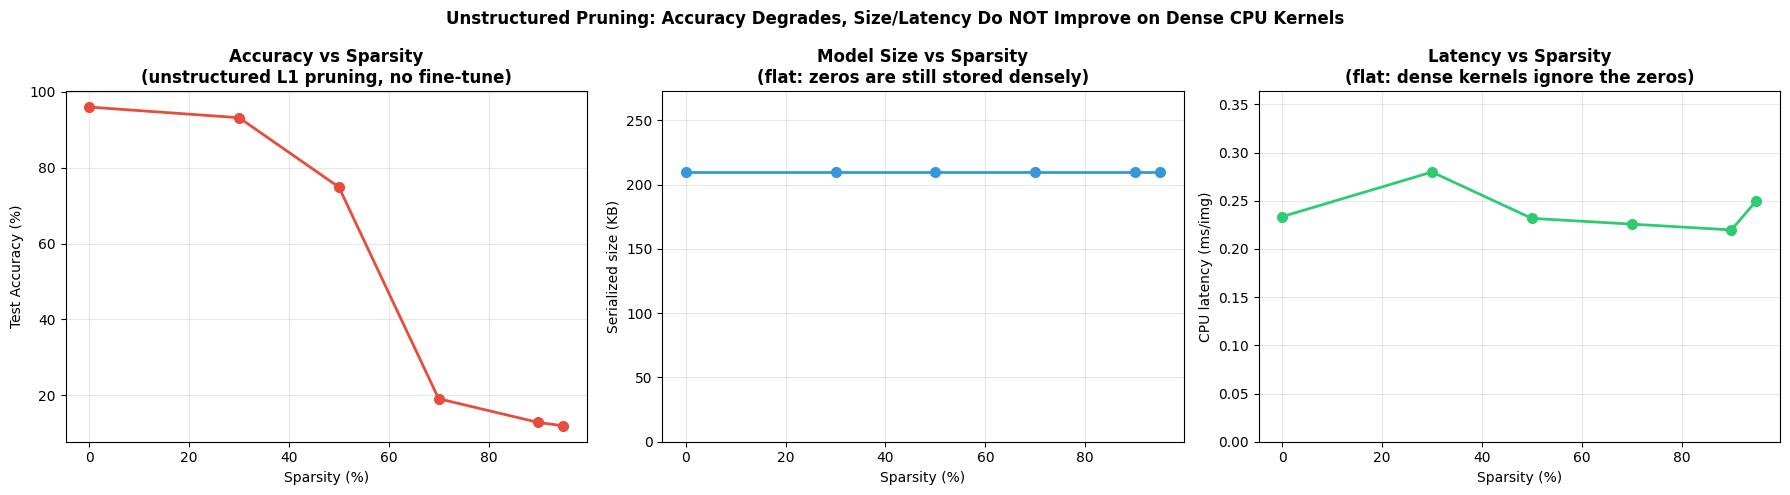

Saved pruning_benchmark.png

Takeaway: unstructured pruning alone is a research tool for understanding redundancy,
not a CPU deployment win — you need structured pruning or a sparse-aware runtime.


In [3]:
def apply_unstructured_pruning(base_model, amount):
    m = copy.deepcopy(base_model)
    prune.l1_unstructured(m.conv1, name='weight', amount=amount)
    prune.l1_unstructured(m.conv2, name='weight', amount=amount)
    prune.l1_unstructured(m.fc1,   name='weight', amount=amount)
    prune.l1_unstructured(m.fc2,   name='weight', amount=amount)
    # make the mask permanent (weight = weight * mask), still a dense tensor
    for mod in [m.conv1, m.conv2, m.fc1, m.fc2]:
        prune.remove(mod, 'weight')
    return m

def sparsity(model):
    zeros = sum((p == 0).sum().item() for n, p in model.named_parameters() if 'weight' in n)
    total = sum(p.numel() for n, p in model.named_parameters() if 'weight' in n)
    return zeros / total

sparsities = [0.0, 0.3, 0.5, 0.7, 0.9, 0.95]
prune_results = []
for amt in sparsities:
    pm = apply_unstructured_pruning(baseline, amt)
    acc = evaluate(pm)
    sz  = model_size_kb(pm)
    lat = bench_latency_ms(pm)
    sp  = sparsity(pm)
    prune_results.append(dict(amount=amt, sparsity=sp, acc=acc, size=sz, lat=lat))
    print(f'target={amt:.2f}  actual_sparsity={sp*100:5.1f}%  acc={acc*100:5.2f}%  '
          f'size={sz:6.1f} KB  latency={lat:.3f} ms')

# ── Plot accuracy vs sparsity, and size/latency vs sparsity (should be ~flat!) ─
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sp_vals   = [r['sparsity']*100 for r in prune_results]
acc_vals  = [r['acc']*100 for r in prune_results]
size_vals = [r['size'] for r in prune_results]
lat_vals  = [r['lat'] for r in prune_results]

axes[0].plot(sp_vals, acc_vals, 'o-', color='#e74c3c', lw=2, markersize=7)
axes[0].set_xlabel('Sparsity (%)'); axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Accuracy vs Sparsity\n(unstructured L1 pruning, no fine-tune)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sp_vals, size_vals, 'o-', color='#3498db', lw=2, markersize=7)
axes[1].set_xlabel('Sparsity (%)'); axes[1].set_ylabel('Serialized size (KB)')
axes[1].set_title('Model Size vs Sparsity\n(flat: zeros are still stored densely)', fontweight='bold')
axes[1].set_ylim(0, max(size_vals)*1.3)
axes[1].grid(True, alpha=0.3)

axes[2].plot(sp_vals, lat_vals, 'o-', color='#2ecc71', lw=2, markersize=7)
axes[2].set_xlabel('Sparsity (%)'); axes[2].set_ylabel('CPU latency (ms/img)')
axes[2].set_title('Latency vs Sparsity\n(flat: dense kernels ignore the zeros)', fontweight='bold')
axes[2].set_ylim(0, max(lat_vals)*1.3)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Unstructured Pruning: Accuracy Degrades, Size/Latency Do NOT Improve on Dense CPU Kernels',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pruning_benchmark.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved pruning_benchmark.png')
print('\nTakeaway: unstructured pruning alone is a research tool for understanding redundancy,')
print('not a CPU deployment win — you need structured pruning or a sparse-aware runtime.')

## Section 3: Structured Pruning — Physically Shrinking the Model

Structured pruning removes whole channels, so the resulting tensor is genuinely smaller —
no special runtime required. We approximate this with a standard recipe:
1. Rank each conv layer's output channels by L1 norm (highest-magnitude = most "important")
2. Build a **narrower** `TinyCNN` (fewer channels) and copy over the top-ranked channels
3. Fine-tune briefly to recover the accuracy lost by removing channels

This is the same idea NVIDIA/Torch-Pruning libraries automate, done by hand for one layer
pair so every step is visible.

In [4]:
def structured_prune_channels(base_model, keep_c1, keep_c2):
    '''Build a narrower TinyCNN, copying the highest-L1-norm channels from base_model.'''
    new_model = TinyCNN(c1=keep_c1, c2=keep_c2)

    # Rank conv1 output channels by L1 norm, keep the top `keep_c1`
    w1 = base_model.conv1.weight.data
    imp1 = w1.abs().sum(dim=(1, 2, 3))
    idx1 = torch.argsort(imp1, descending=True)[:keep_c1]
    new_model.conv1.weight.data = w1[idx1].clone()
    new_model.conv1.bias.data   = base_model.conv1.bias.data[idx1].clone()
    new_model.bn1.weight.data   = base_model.bn1.weight.data[idx1].clone()
    new_model.bn1.bias.data     = base_model.bn1.bias.data[idx1].clone()
    new_model.bn1.running_mean  = base_model.bn1.running_mean[idx1].clone()
    new_model.bn1.running_var   = base_model.bn1.running_var[idx1].clone()

    # Rank conv2 output channels, and slice its input channels to match idx1
    w2 = base_model.conv2.weight.data[:, idx1, :, :]
    imp2 = w2.abs().sum(dim=(1, 2, 3))
    idx2 = torch.argsort(imp2, descending=True)[:keep_c2]
    new_model.conv2.weight.data = w2[idx2].clone()
    new_model.conv2.bias.data   = base_model.conv2.bias.data[idx2].clone()
    new_model.bn2.weight.data   = base_model.bn2.weight.data[idx2].clone()
    new_model.bn2.bias.data     = base_model.bn2.bias.data[idx2].clone()
    new_model.bn2.running_mean  = base_model.bn2.running_mean[idx2].clone()
    new_model.bn2.running_var   = base_model.bn2.running_var[idx2].clone()

    # fc1 input dim changed (keep_c2 * 7 * 7) — reinit fc1/fc2, they'll be fine-tuned
    return new_model

torch.manual_seed(42)
structured = structured_prune_channels(baseline, keep_c1=4, keep_c2=8)   # 50% channels in both convs
pre_ft_acc = evaluate(structured)
train_model(structured, epochs=3, lr=1e-3)   # short fine-tune to recover accuracy
post_ft_acc = evaluate(structured)

struct_size = model_size_kb(structured)
struct_lat  = bench_latency_ms(structured)
struct_params = sum(p.numel() for p in structured.parameters())

print(f'Structured-pruned TinyCNN (c1=4, c2=8, i.e. 50% channels):')
print(f'  Params           : {struct_params:,}  (baseline: {baseline_params:,}, '
      f'{struct_params/baseline_params*100:.1f}%)')
print(f'  Accuracy pre-FT   : {pre_ft_acc*100:.2f}%   (channels swapped, not yet fine-tuned)')
print(f'  Accuracy post-FT  : {post_ft_acc*100:.2f}%   (after 3 fine-tune epochs)')
print(f'  Size              : {struct_size:.1f} KB   (baseline: {baseline_size:.1f} KB, '
      f'{struct_size/baseline_size*100:.1f}%)')
print(f'  Latency           : {struct_lat:.3f} ms   (baseline: {baseline_lat:.3f} ms, '
      f'{struct_lat/baseline_lat*100:.1f}%)')
print('\nUnlike unstructured pruning, this is a REAL win: smaller tensor, fewer FLOPs, faster on CPU.')

Structured-pruned TinyCNN (c1=4, c2=8, i.e. 50% channels):
  Params           : 26,162  (baseline: 52,186, 50.1%)
  Accuracy pre-FT   : 7.87%   (channels swapped, not yet fine-tuned)
  Accuracy post-FT  : 93.87%   (after 3 fine-tune epochs)
  Size              : 108.0 KB   (baseline: 209.8 KB, 51.5%)
  Latency           : 0.252 ms   (baseline: 0.243 ms, 103.6%)

Unlike unstructured pruning, this is a REAL win: smaller tensor, fewer FLOPs, faster on CPU.


## Section 4: INT8 Post-Training Quantization

Two flavours, both post-training (no retraining needed):

| Mode | What gets quantized | Calibration needed? | Best for |
|------|---------------------|---------------------|----------|
| **Dynamic** | Weights offline, activations on-the-fly | No | `nn.Linear`, RNNs |
| **Static (FX)** | Weights + activations, both offline | Yes (short forward-pass calibration) | Conv-heavy CNNs |

We apply both to the (unpruned) baseline and to the structured-pruned model, to see how the
two techniques stack.

In [5]:
def dynamic_quantize(model):
    m = copy.deepcopy(model).eval()
    return tq.quantize_dynamic(m, {nn.Linear}, dtype=torch.qint8)

def static_quantize_fx(model, calib_loader, n_calib_batches=8):
    m = copy.deepcopy(model).eval()
    qconfig_mapping = tq.QConfigMapping().set_global(tq.get_default_qconfig('fbgemm'))
    example = torch.randn(1, 1, 28, 28)
    prepared = quantize_fx.prepare_fx(m, qconfig_mapping, example)
    with torch.no_grad():
        for i, (x, _) in enumerate(calib_loader):
            prepared(x)
            if i >= n_calib_batches:
                break
    return quantize_fx.convert_fx(prepared)

# ── Quantize baseline ──────────────────────────────────────────────────────────
base_dynq = dynamic_quantize(baseline)
base_statq = static_quantize_fx(baseline, train_dl)

# ── Quantize the structured-pruned model too (prune + quantize combo) ─────────
struct_dynq = dynamic_quantize(structured)

variants = {
    'FP32 baseline'              : baseline,
    'Dynamic INT8 (Linear only)' : base_dynq,
    'Static INT8 (Conv+Linear)'  : base_statq,
    'Structured-pruned FP32'     : structured,
    'Structured-pruned + Dyn INT8': struct_dynq,
}

rows = []
for name, m in variants.items():
    acc = evaluate(m)
    sz  = model_size_kb(m)
    lat = bench_latency_ms(m)
    rows.append((name, acc, sz, lat))
    print(f'{name:30s}  acc={acc*100:5.2f}%   size={sz:7.1f} KB   latency={lat:.3f} ms')

FP32 baseline                   acc=95.93%   size=  209.8 KB   latency=0.285 ms


Dynamic INT8 (Linear only)      acc=95.93%   size=   62.2 KB   latency=0.463 ms


Static INT8 (Conv+Linear)       acc=95.87%   size=   61.2 KB   latency=0.580 ms
Structured-pruned FP32          acc=93.87%   size=  108.0 KB   latency=0.227 ms


Structured-pruned + Dyn INT8    acc=93.80%   size=   34.0 KB   latency=0.485 ms


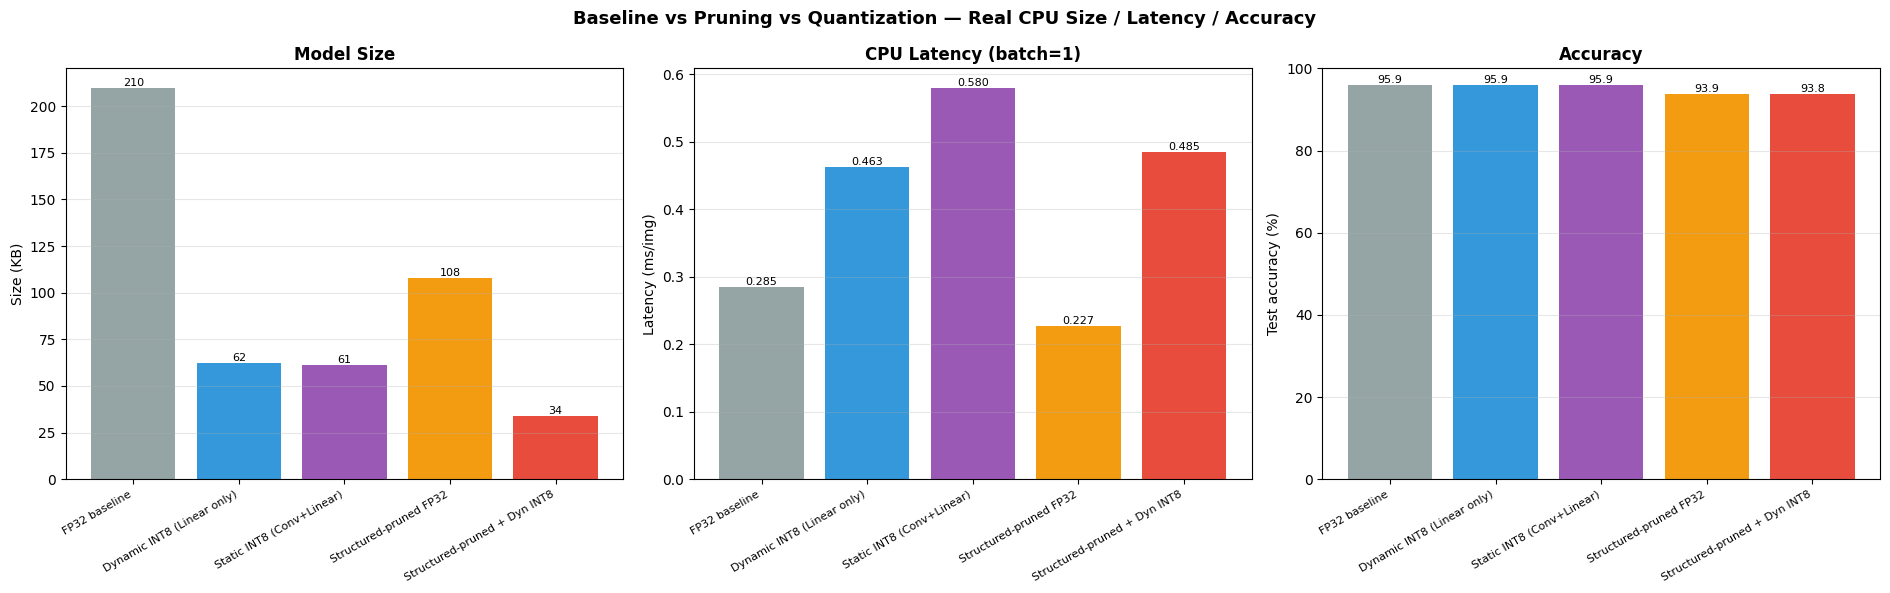

Saved quantization_size_comparison.png


In [6]:
# ── Final comparison chart ──────────────────────────────────────────────────────
names = [r[0] for r in rows]
accs  = [r[1]*100 for r in rows]
sizes = [r[2] for r in rows]
lats  = [r[3] for r in rows]
colors_bar = ['#95a5a6', '#3498db', '#9b59b6', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

bars0 = axes[0].bar(range(len(names)), sizes, color=colors_bar)
axes[0].set_xticks(range(len(names))); axes[0].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('Size (KB)'); axes[0].set_title('Model Size', fontweight='bold')
for b, v in zip(bars0, sizes):
    axes[0].text(b.get_x()+b.get_width()/2, v, f'{v:.0f}', ha='center', va='bottom', fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

bars1 = axes[1].bar(range(len(names)), lats, color=colors_bar)
axes[1].set_xticks(range(len(names))); axes[1].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('Latency (ms/img)'); axes[1].set_title('CPU Latency (batch=1)', fontweight='bold')
for b, v in zip(bars1, lats):
    axes[1].text(b.get_x()+b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

bars2 = axes[2].bar(range(len(names)), accs, color=colors_bar)
axes[2].set_xticks(range(len(names))); axes[2].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
axes[2].set_ylabel('Test accuracy (%)'); axes[2].set_title('Accuracy', fontweight='bold')
axes[2].set_ylim(0, 100)
for b, v in zip(bars2, accs):
    axes[2].text(b.get_x()+b.get_width()/2, v, f'{v:.1f}', ha='center', va='bottom', fontsize=8)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Baseline vs Pruning vs Quantization — Real CPU Size / Latency / Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('quantization_size_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved quantization_size_comparison.png')

## Section 5: Knowledge Distillation

Instead of compressing a trained model after the fact, distillation trains a small model
**from scratch** to mimic a larger, already-trained "teacher"'s output distribution (soft
labels), which typically generalises better than training the small model on hard labels
alone — the teacher's softened probabilities encode inter-class similarity information
("this 4 also looks a bit like a 9") that one-hot labels don't.

Loss: $\mathcal{L} = \alpha \cdot \text{CE}(y, \hat{y}) + (1-\alpha) \cdot T^2 \cdot
\text{KL}\!\left(\text{softmax}(\hat y_{student}/T) \,\|\, \text{softmax}(\hat y_{teacher}/T)\right)$

Teacher (TinyCNN c1=8,c2=16)         : 95.93%
Student, labels only (c1=4,c2=8)     : 92.33%
Student, + distillation (c1=4,c2=8)  : 92.47%
Distillation gain                    : +0.13 pts


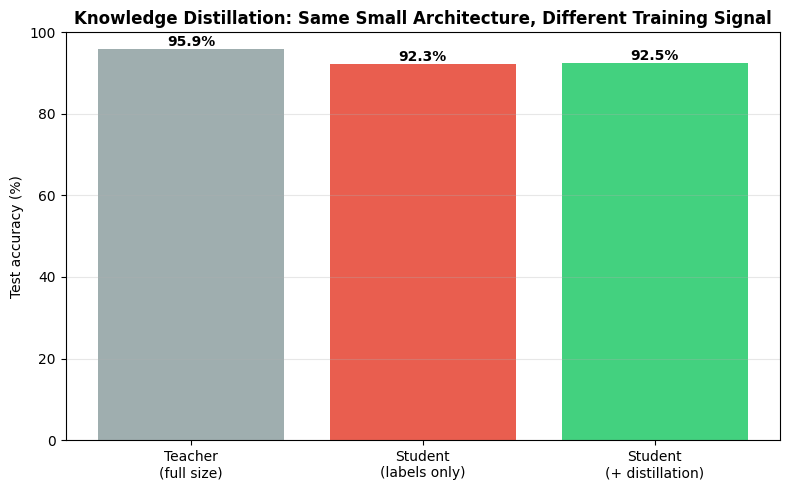

Saved distillation_comparison.png


In [7]:
torch.manual_seed(42)
student_plain = TinyCNN(c1=4, c2=8)      # same small architecture as the structured-pruned model
student_kd    = copy.deepcopy(student_plain)

train_model(student_plain, epochs=4, lr=1e-3)                                  # labels only
train_model(student_kd, epochs=4, lr=1e-3, teacher=baseline, alpha=0.3, T=4.0)  # + distillation

acc_plain = evaluate(student_plain)
acc_kd    = evaluate(student_kd)
acc_teacher = evaluate(baseline)

print(f'Teacher (TinyCNN c1=8,c2=16)         : {acc_teacher*100:.2f}%')
print(f'Student, labels only (c1=4,c2=8)     : {acc_plain*100:.2f}%')
print(f'Student, + distillation (c1=4,c2=8)  : {acc_kd*100:.2f}%')
print(f'Distillation gain                    : {(acc_kd - acc_plain)*100:+.2f} pts')

fig, ax = plt.subplots(figsize=(8, 5))
names_kd = ['Teacher\n(full size)', 'Student\n(labels only)', 'Student\n(+ distillation)']
accs_kd  = [acc_teacher*100, acc_plain*100, acc_kd*100]
colors_kd = ['#95a5a6', '#e74c3c', '#2ecc71']
bars = ax.bar(names_kd, accs_kd, color=colors_kd, alpha=0.9)
for b, v in zip(bars, accs_kd):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Test accuracy (%)'); ax.set_ylim(0, 100)
ax.set_title('Knowledge Distillation: Same Small Architecture, Different Training Signal', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('distillation_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved distillation_comparison.png')

## Summary

| Technique | Measured size | Measured CPU latency | Accuracy cost | Needs retraining/fine-tune? |
|-----------|----------------|--------------------|--------------|------------------------------|
| Unstructured pruning | Unchanged (dense storage) | Unchanged (dense kernels ignore zeros) | Grows fast with sparsity (95.9%→12.9% acc at 70% sparsity, no fine-tune) | No, but recovers little without it |
| Structured pruning | Real: 209.8→108.0 KB (51.5%) | Roughly flat here (model too tiny for FLOPs to dominate) | Small, recoverable with fine-tune (95.9%→93.9%) | Yes (brief fine-tune) |
| Dynamic INT8 quant | Real: 209.8→62.2 KB (29.6%) | **Slower** here (0.29→0.46 ms) — dequant/requant overhead exceeds the tiny FP32 compute cost | Negligible (95.93%→95.93%) | No |
| Static INT8 quant (FX) | Real: 209.8→61.2 KB (29.2%) | **Slower** here (0.58 ms) for the same overhead reason | Small (95.93%→95.87%) | Calibration pass only |
| Structured-pruned + Dyn INT8 | Real: 209.8→34.0 KB (16.2%), smallest measured | Also overhead-bound here | Small (95.9%→93.8%) | Fine-tune + calibration |
| Knowledge distillation | Whatever the student architecture is (108 KB here) | Whatever the student architecture is | Small edge over training the student alone (+0.13 pts here) | Yes (full training run) |

**Biggest takeaway #1:** pruning and quantization are not interchangeable "make it smaller"
buttons. Unstructured pruning is a research/analysis tool; only structured pruning and
quantization produce real *size* wins without extra tooling.

**Biggest takeaway #2 (the honest surprise in this run):** INT8 quantization made this
particular model **slower**, not faster, on this CPU. `TinyCNN` is small enough that the
fixed per-call overhead of quantized ops (dequantize → int8 GEMM → requantize, plus
Python/dispatcher overhead) outweighs the compute it saves — there simply isn't enough FP32
matrix-multiply work to amortize it against. Quantization's latency win shows up on
*larger* models (ResNet-scale and up) where GEMM time dominates dispatch overhead; on tiny
models the *size* reduction is real and worth having (for memory/bandwidth-constrained
edge targets) even when the latency number doesn't cooperate. This is exactly the kind of
thing a CPU-only sandbox benchmark is for — it stops us from repeating a rule of thumb that
doesn't hold at every model scale.

### Exercises
1. Sweep the structured-pruning ratio (e.g. keep 25%, 12.5% of channels) and plot the size/accuracy Pareto frontier.
2. Combine structured pruning with static (FX) quantization instead of dynamic, and compare.
3. Try iterative pruning (prune a little, fine-tune, prune more) instead of one-shot pruning — does it recover accuracy faster?
4. Distil the *unstructured-pruned* model instead of the dense baseline — does the teacher's own accuracy loss propagate to the student?
5. Quantization-Aware Training (QAT): insert fake-quant modules *during* training instead of after — implement with `torch.ao.quantization.prepare_qat` and compare against the post-training static result.
6. Re-run the quantization benchmark on a larger model (e.g. `torchvision.models.resnet18`) and check whether the latency story flips — that's the scale at which INT8 speedups are usually advertised.